In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from torchvision.models import ResNet50_Weights, resnet50
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
import scipy.io
import h5py
import seaborn as sns
from typing import Optional, Tuple
from sklearn.preprocessing import LabelEncoder
from utils import build_transforms, StanfordCarsDataset, save_confusion_outputs, prepare_dataframe, evaluate_predictions
from sklearn.model_selection import train_test_split

### intialization and setup

In [2]:
# Change this to the number of classes used during training.
num_classes = 196
checkpoint_path = Path("./outputs/best_resnet50_stanford_cars.pt")
ANNO_FILE = "./archive/cars_train/cars_train_annos.mat"
META_FILE = "./archive/cars_meta.mat"  

# Use GPU when available, otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cpu


#### functions and classes

In [3]:
def load_annotation_file(filepath: Path):
    """Load a MATLAB .mat annotation file using scipy first, then h5py for v7.3 files."""
    if not filepath.exists():
        raise FileNotFoundError(f"Annotation file not found: {filepath}")

    try:
        mat_data = scipy.io.loadmat(filepath)
        return mat_data, "scipy"
    except NotImplementedError:
        mat_data = h5py.File(filepath, "r")
        return mat_data, "h5py"

def build_resnet50(num_classes: int) -> nn.Module:
    try:
        model = resnet50(weights=ResNet50_Weights.DEFAULT)
    except Exception:
        # If pretrained weights cannot be downloaded, keep the architecture only.
        model = resnet50(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def infer_num_classes_from_state_dict(state_dict, fallback_num_classes: int) -> int:
    fc_weight = state_dict.get("fc.weight") if isinstance(state_dict, dict) else None
    if isinstance(fc_weight, torch.Tensor) and fc_weight.ndim == 2:
        return fc_weight.shape[0]
    return fallback_num_classes

def load_model_weights(model: nn.Module, checkpoint_path: Path, device: torch.device) -> nn.Module:
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location=device)

    if isinstance(checkpoint, dict):
        state_dict = checkpoint.get("model_state_dict", checkpoint.get("state_dict", checkpoint))
    else:
        state_dict = checkpoint

    inferred_num_classes = infer_num_classes_from_state_dict(state_dict, model.fc.out_features)
    if model.fc.out_features != inferred_num_classes:
        model.fc = nn.Linear(model.fc.in_features, inferred_num_classes)

    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model

def get_preprocess_transform() -> transforms.Compose:
    return transforms.Compose(
        [
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ]
    )

def predict_image(image_path: str | Path, model: nn.Module, transform: transforms.Compose, device: torch.device):
    image_path = Path(image_path)
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probabilities = torch.softmax(logits, dim=1)
        confidence, predicted_index = torch.max(probabilities, dim=1)

    return image, predicted_index.item(), confidence.item()

### load model and weights

In [4]:
# Instantiate and load the trained checkpoint.
print(f"Number of classes: {num_classes}")
model = build_resnet50(num_classes=num_classes)


Number of classes: 196


In [5]:
# eheck if the checkpoint file exists before attempting to load it
if not checkpoint_path.is_file():
    raise FileNotFoundError(f"Checkpoint file not found at: {checkpoint_path}")
best_checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)


In [6]:
print(best_checkpoint.keys())
# print first 5 keys and their types
for key in list(best_checkpoint.keys())[:5]:
    print(f"{key}: {type(best_checkpoint[key])}")

dict_keys(['epoch', 'model_state_dict', 'label_classes'])
epoch: <class 'int'>
model_state_dict: <class 'collections.OrderedDict'>
label_classes: <class 'numpy.ndarray'>


In [7]:
# Load the model weights and move it to the appropriate device.
model.load_state_dict(best_checkpoint["model_state_dict"])
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [8]:
# define the image transformation pipeline
transform = get_preprocess_transform()

### load anno file

In [9]:
metadata = load_annotation_file(Path(META_FILE))
# convert metadata to a dataframe directly
class_names = metadata[0]["class_names"].squeeze()
meta_df = pd.DataFrame({
    "class_id": np.arange(1, class_names.size + 1),
    "class_name": [cls.item() for cls in class_names]
})

print(meta_df.head())

   class_id                  class_name
0         1  AM General Hummer SUV 2000
1         2         Acura RL Sedan 2012
2         3         Acura TL Sedan 2012
3         4        Acura TL Type-S 2008
4         5        Acura TSX Sedan 2012


### inference on a sample image

In [10]:
# Example image from the local Stanford Cars test set.
sample_image_path = Path("./archive/cars_test/cars_test/00001.jpg")
image, predicted_class_idx, confidence = predict_image(sample_image_path, model, transform, device)


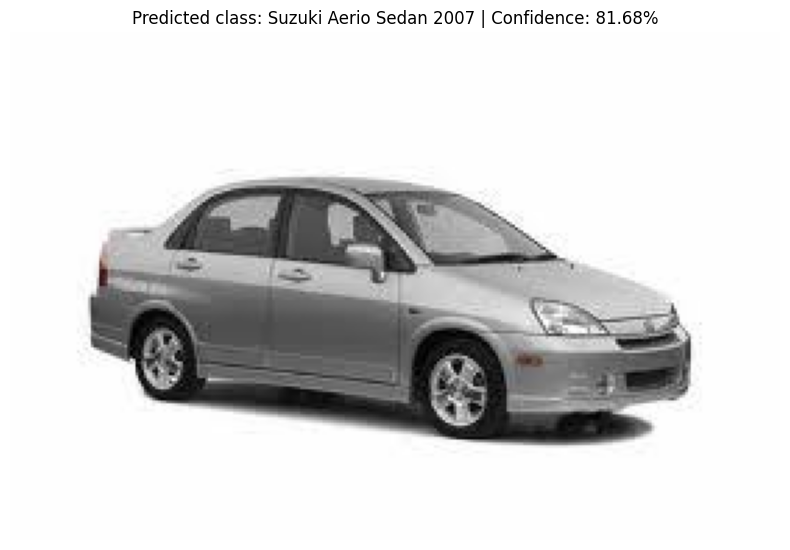

In [11]:

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.title(f"Predicted class: {meta_df.iloc[predicted_class_idx]['class_name']} | Confidence: {confidence:.2%}")
plt.tight_layout()
plt.show()


### Saliency maps

In [12]:
# Saliency logic
def compute_saliency(image_path, model, transform, device):
    orig_img, display_img = open_image_for_display(image_path)
    input_tensor = transform(orig_img).unsqueeze(0).to(device)
    input_tensor.requires_grad_()
    model.zero_grad()
    outputs = model(input_tensor)            # logits
    top_idx = outputs.argmax(dim=1).item()
    score = outputs[0, top_idx]
    score.backward()
    saliency = input_tensor.grad.data.abs().squeeze(0)   # (C, H, W)
    saliency, _ = torch.max(saliency, dim=0)           # (H, W)
    saliency = saliency.cpu().numpy()
    # Normalize to [0,1]
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    return display_img, saliency, top_idx

# Visualization: original and saliency heatmap side-by-side
def open_image_for_display(path):
    img = Image.open(path).convert("RGB")
    img_disp = img.resize((224, 224))
    return img, img_disp
def plot_saliency(display_img, saliency, cmap="hot"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(display_img)
    axes[0].axis("off")
    axes[0].set_title("Original")
    im = axes[1].imshow(saliency, cmap=cmap)
    axes[1].axis("off")
    axes[1].set_title("Vanilla Saliency Map")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

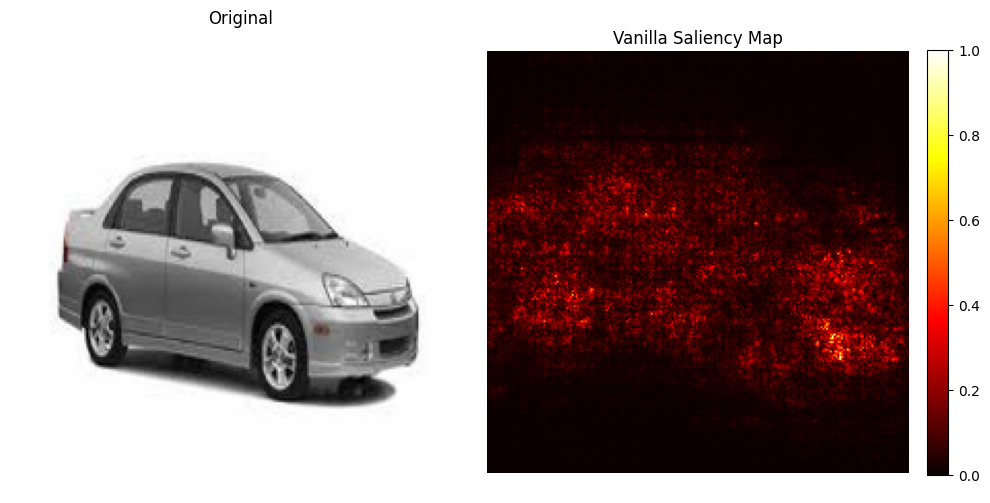

Predicted class index: Suzuki Aerio Sedan 2007


In [13]:
display_img, saliency_map, predicted_class = compute_saliency(sample_image_path, model, val_transform, device)
plot_saliency(display_img, saliency_map)
print("Predicted class index:", meta_df.iloc[predicted_class_idx]['class_name'])

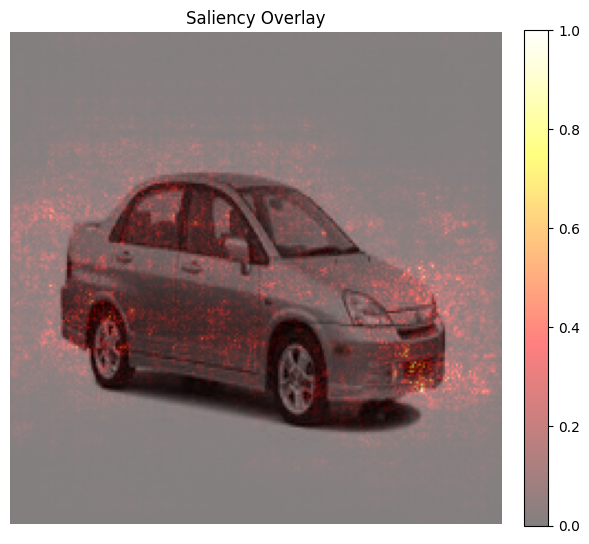

In [14]:
# overlay saliency on original image
def plot_saliency_overlay(display_img, saliency, alpha=0.5, cmap="hot"):
    plt.figure(figsize=(6, 6))
    plt.imshow(display_img)
    plt.imshow(saliency, cmap=cmap, alpha=alpha)
    plt.axis("off")
    plt.title("Saliency Overlay")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
plot_saliency_overlay(display_img, saliency_map)